**Table of contents**<a id='toc0_'></a>    
- [Modeling PFA of 4 fluorophores at 3 nm](#toc1_)    
  - [Reading data](#toc1_1_)    
  - [Fitting data](#toc1_2_)    
  - [CDF of deltas](#toc1_3_)    
  - [PDF of deltas](#toc1_4_)    
  - [Evaluating the fit to the PFA](#toc1_5_)    
  - [Saving the fit](#toc1_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Modeling PFA of 4 fluorophores at 3 nm](#toc0_)

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.distributions as dist
import fluopy.figure as fi
import fluopy.fitting as fitting
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

num_f = 4
distance = "3nm"
reading_from = (
    rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA\{num_f}F"
)
saving_to = rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling\{num_f}F\{distance}"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading data](#toc0_)

In [3]:
n_runs = 500
total_photons = 4.5e8  # n runs where all fluorophores of the current bleaching index
# photobleach
photons_per_f = total_photons / n_runs  # maximum number of photons per bleaching event

### Using only subsets of data

In [ ]:
subset_size = 100
runs = int(n_runs / subset_size)
counters = []
parameter_collector = []
rng = np.random.default_rng(42)
for i_run in range(runs):
    bleaching_times = np.load(reading_from + f"/bleaching_times_{distance}.npy")
    bleaching_times = bleaching_times[
        i_run * subset_size : (i_run + 1) * subset_size, :
    ]
    delta_bleaching_times = rt.get_delta_bleaching_times(bleaching_times)
    rel_num_not_observed = [
        1 - delta.size / subset_size for delta in delta_bleaching_times
    ]

    rel_num_not_observed_all = np.sum(rel_num_not_observed) / len(rel_num_not_observed)
    num_not_observed_all = rel_num_not_observed_all * total_photons * num_f

    fair_num_not_observed = []
    fair_rel_num_not_observed = []
    for i, delta in enumerate(delta_bleaching_times):
        if i == 0:
            size = subset_size
        else:
            size = delta_bleaching_times[i - 1].size
        curr_size = delta_bleaching_times[i].size
        fair_num_not_observed.append((size - curr_size) * photons_per_f)
        fair_rel_num_not_observed.append(1 - delta.size / size)
    # the fair_rel_num_not_observed or in general the rel_num_not_observed
    # can be used via fair_rel_num / (1-fair_rel_num), which results in a factor with which
    # the number of observed events has to be multiplied to get the number of missed events
    # however if rel_num is 1, this factor becomes infinite, thats why the photon_per_f
    # approach is better here
    ##################################################################################
    x = np.linspace(0, 300, 300001)
    fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
    bleaching_times_index = 0
    bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
    photon_arrival_times_log = np.zeros(len(bin_edges_log) - 1, dtype=int)
    delta_photon_arrival_times_binned = [
        np.zeros(len(bin_edges_log) - 1, dtype=int) for _ in range(num_f)
    ]
    rvs = []
    for counter, file in enumerate(Path(reading_from).iterdir()):
        if (
            file.suffix == ".parquet"
            and distance in file.name
            and counter not in counters
        ):
            counters.append(counter)
            df = pd.read_parquet(file)
            fingerprint += df.sum(axis=1)
            for i in range(len(df.columns)):
                start_index = 0
                for n in range(num_f):
                    time_point = bleaching_times[bleaching_times_index + i, n]
                    if not np.isnan(time_point):
                        end_index = (
                            np.searchsorted(
                                df.iloc[:, i].index.values, time_point, side="right"
                            )
                            + 1
                        )
                    else:
                        end_index = df.index.size
                    data = np.repeat(
                        df.iloc[:, i].index.values[start_index:end_index],
                        df.iloc[:, i].iloc[start_index:end_index].values.astype(int),
                    )
                    rvs.extend(
                        rng.choice(data, size=int(0.1 * data.size), replace=True)
                    )
                    hist_log, _ = np.histogram(data, bins=bin_edges_log)
                    photon_arrival_times_log += hist_log
                    if data.size != 0:
                        delta_data = data - df.index.values[start_index] + 0.01
                        delta_hist, _ = np.histogram(delta_data, bins=bin_edges_log)
                        delta_photon_arrival_times_binned[n] += delta_hist
                    start_index = end_index
            bleaching_times_index += 50
            if bleaching_times_index >= subset_size:
                break

    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    ###########################################################################
    z = 2
    result = fitting.fit_multiple_mixture_v1(
        datasets=delta_photon_arrival_times_binned,
        bin_edges=bin_edges_log,
        maxiter=1000,
        popsize=200,
        norm=False,
        constr=True,
        disp=False,
        z=z,
        counts_not_observed=fair_num_not_observed,
        seed=rng,
        polish=False,
        # pfa_counts=photon_arrival_times_log,
        # pfa_bin_edges=bin_edges_log,
        # pfa_counts_not_observed=num_not_observed_all,
    )

    parameter_dict_pfa = fitting.prepare_pfa_parameters(z=z, n=num_f, params=result.x)
    parameter_dict_exp_mixture = fitting.prepare_exp_mixture_parameters(
        z=z, n=num_f, params=result.x
    )
    parameter_collector.append(parameter_dict_pfa)

In [22]:
parameter_collector

[{0: [np.float64(0.031119984064979678),
   np.float64(0.9688800159350204),
   np.float64(4.941774409699738),
   np.float64(0.7541651675090635)],
  1: [np.float64(0.023868516637785497),
   np.float64(0.9761314833622146),
   np.float64(4.832944116780945),
   np.float64(0.7461179259863024)],
  2: [np.float64(0.023502680504904505),
   np.float64(0.614803080645345),
   np.float64(0.3616942388497505),
   np.float64(4.780564133642043),
   np.float64(0.01680745161075592),
   np.float64(0.7260013613632597)],
  3: [np.float64(0.0073049283647064756),
   np.float64(0.9926950716352936),
   np.float64(4.733970358675814),
   np.float64(0.00039796293476390687)]},
 {0: [np.float64(0.8125758827769148),
   np.float64(0.18742411722308516),
   np.float64(0.8501386896576297),
   np.float64(0.8229443436750228)],
  1: [np.float64(0.7617901393404346),
   np.float64(0.2382098606595654),
   np.float64(0.80720628433093),
   np.float64(0.3219345264950313)],
  2: [np.float64(0.33580080928564354),
   np.float64(0.19

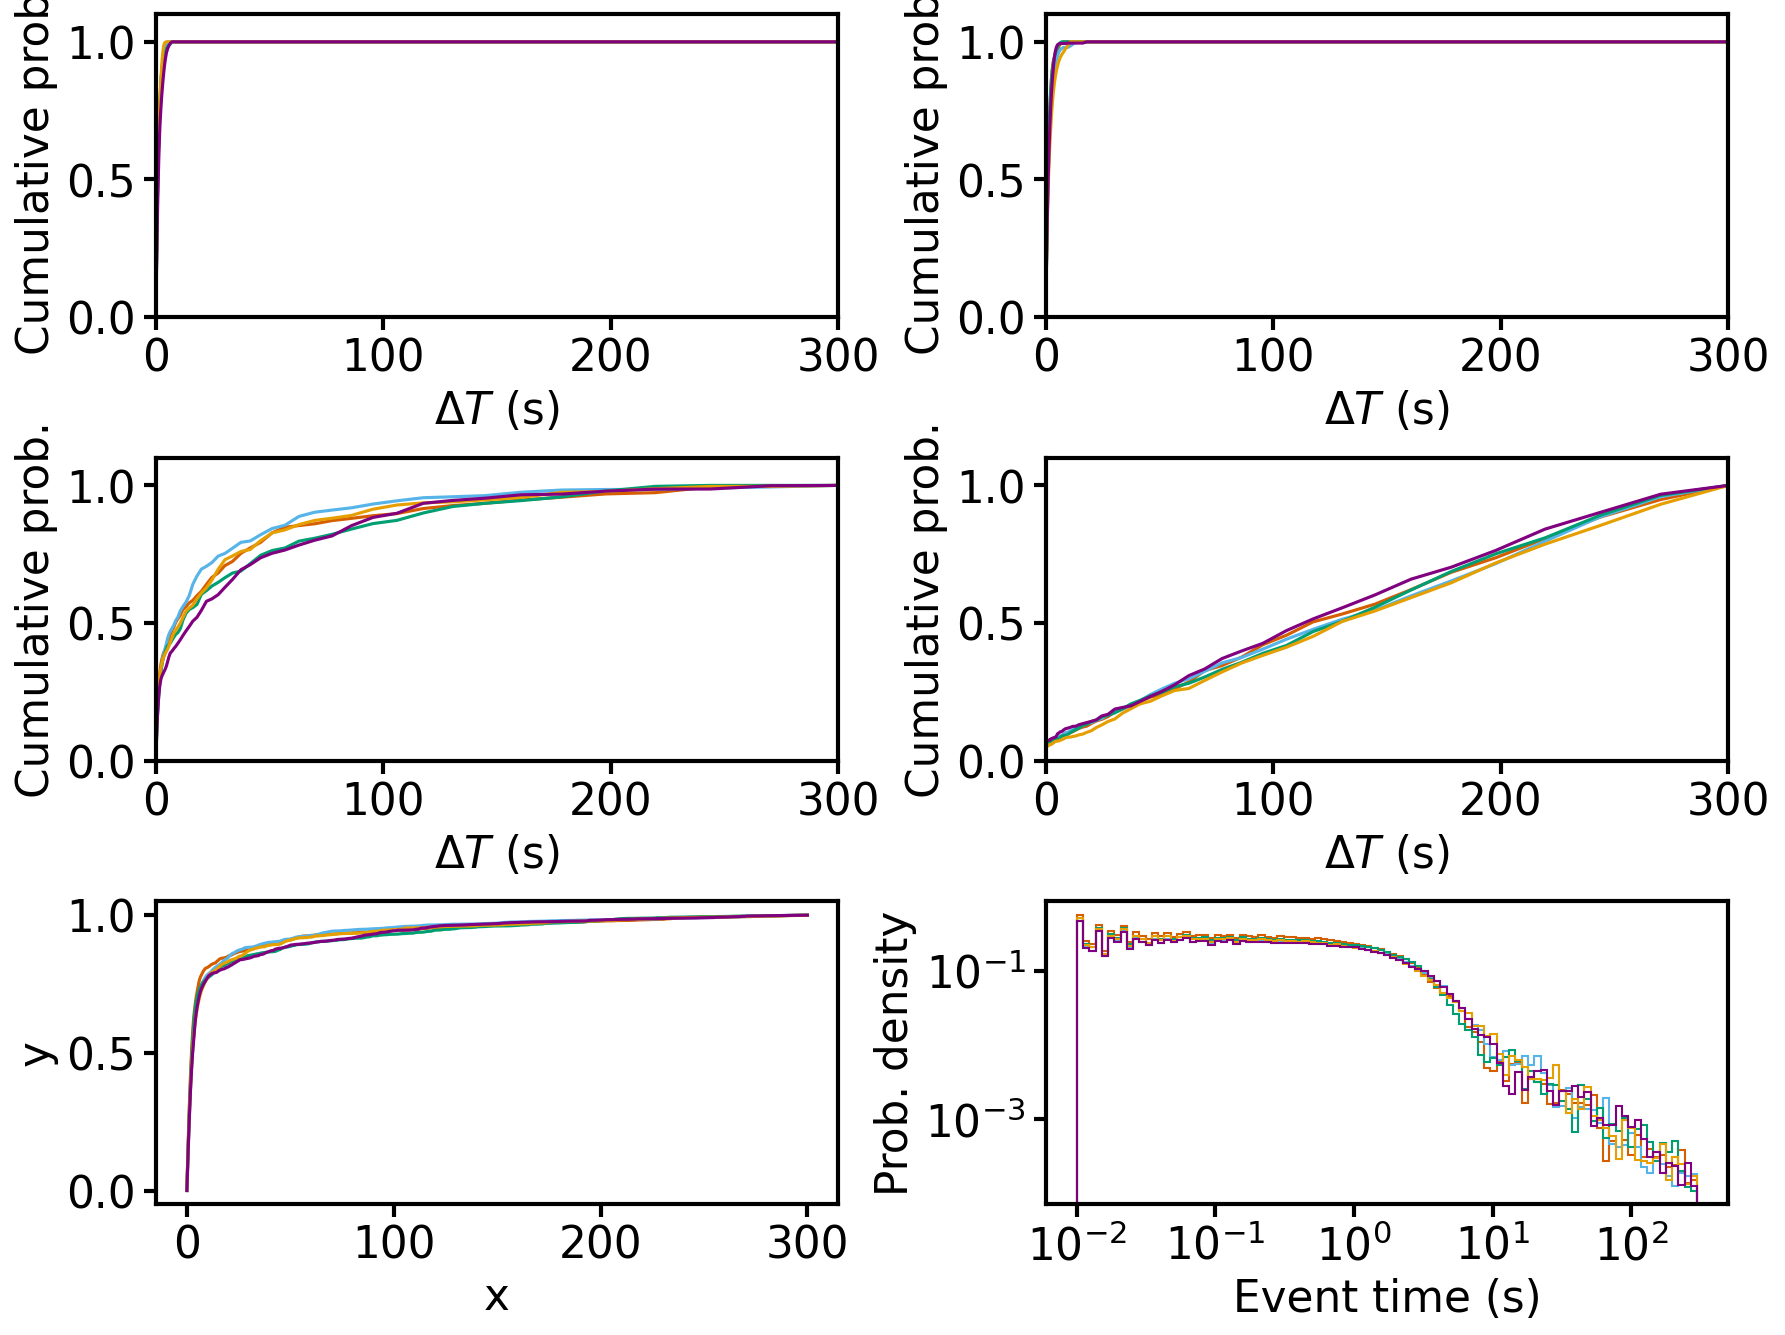

In [23]:
rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange, "purple", "brown"]
fig, ax = plt.subplots(3, 2, figsize=(12, 9), dpi=150)
subset_size = 100
runs = int(n_runs / subset_size)
counters = []
rng = np.random.default_rng(42)

for i_run in range(runs):
    bleaching_times = np.load(reading_from + f"/bleaching_times_{distance}.npy")
    bleaching_times = bleaching_times[
        i_run * subset_size : (i_run + 1) * subset_size, :
    ]
    delta_bleaching_times = rt.get_delta_bleaching_times(bleaching_times)
    rel_num_not_observed = [
        1 - delta.size / subset_size for delta in delta_bleaching_times
    ]

    ##################################################################################
    x = np.linspace(0, 300, 300001)
    fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
    locs = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    bleaching_times_index = 0
    bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
    photon_arrival_times_log = np.zeros(len(bin_edges_log) - 1, dtype=int)
    delta_photon_arrival_times_binned = [
        np.zeros(len(bin_edges_log) - 1, dtype=int) for _ in range(num_f)
    ]
    rvs = []
    for counter, file in enumerate(Path(reading_from).iterdir()):
        if (
            file.suffix == ".parquet"
            and distance in file.name
            and counter not in counters
        ):
            counters.append(counter)
            df = pd.read_parquet(file)
            fingerprint += df.sum(axis=1)
            locs += (df > 0).sum(axis=1)
            for i in range(len(df.columns)):
                start_index = 0
                for n in range(num_f):
                    time_point = bleaching_times[bleaching_times_index + i, n]
                    if not np.isnan(time_point):
                        end_index = (
                            np.searchsorted(
                                df.iloc[:, i].index.values, time_point, side="right"
                            )
                            + 1
                        )
                    else:
                        end_index = df.index.size
                    data = np.repeat(
                        df.iloc[:, i].index.values[start_index:end_index],
                        df.iloc[:, i].iloc[start_index:end_index].values.astype(int),
                    )
                    rvs.extend(
                        rng.choice(data, size=int(0.1 * data.size), replace=True)
                    )
                    hist_log, _ = np.histogram(data, bins=bin_edges_log)
                    photon_arrival_times_log += hist_log
                    if data.size != 0:
                        delta_data = data - df.index.values[start_index] + 0.01
                        delta_hist, _ = np.histogram(delta_data, bins=bin_edges_log)
                        delta_photon_arrival_times_binned[n] += delta_hist
                    start_index = end_index
            bleaching_times_index += 50
            if bleaching_times_index >= subset_size:
                break

    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    locs = locs.cumsum() / locs.sum()
    locs_truncated = rt.truncate_fingerprints(locs, low=3000)
    for i, delta in enumerate(delta_photon_arrival_times_binned):
        axis = ax.flatten()[i]
        cdf = np.cumsum(delta) / delta.sum()
        cdf = np.insert(cdf, 0, 0)
        fi.universal_figure(
            data=[bin_edges_log, cdf],
            axes=axis,
            color=colors[i_run],
            xlabel=r"$\Delta T$ (s)",
            ylabel="Cumulative prob.",
            xlim=(0, 300),
            ylim=(0, 1.1),
        )
    bin_widths = np.diff(bin_edges_log)
    density = photon_arrival_times_log / (photon_arrival_times_log.sum() * bin_widths)
    fi.universal_figure(
        type_="stair",
        data=[bin_edges_log, density],
        axes=ax.flatten()[-1],
        color=colors[i_run],
        label="Photons",
        xlabel="Event time (s)",
        ylabel="Prob. density",
        xscale="log",
        yscale="log",
    )
    fi.universal_figure(
        data=[fingerprint.index, fingerprint.values],
        axes=ax.flatten()[-2],
        color=colors[i_run],
        label="PFA",
    )
    # fi.universal_figure(
    #     data=[locs_truncated.index, locs_truncated.values],
    #     axes=ax.flatten()[-2],
    #     color=colors[i_run],
    #     label="PFA",
    #     ylabel="Cumulative prob.",
    #     xlabel="Loc detec time (s)"
    # )

fig.tight_layout()

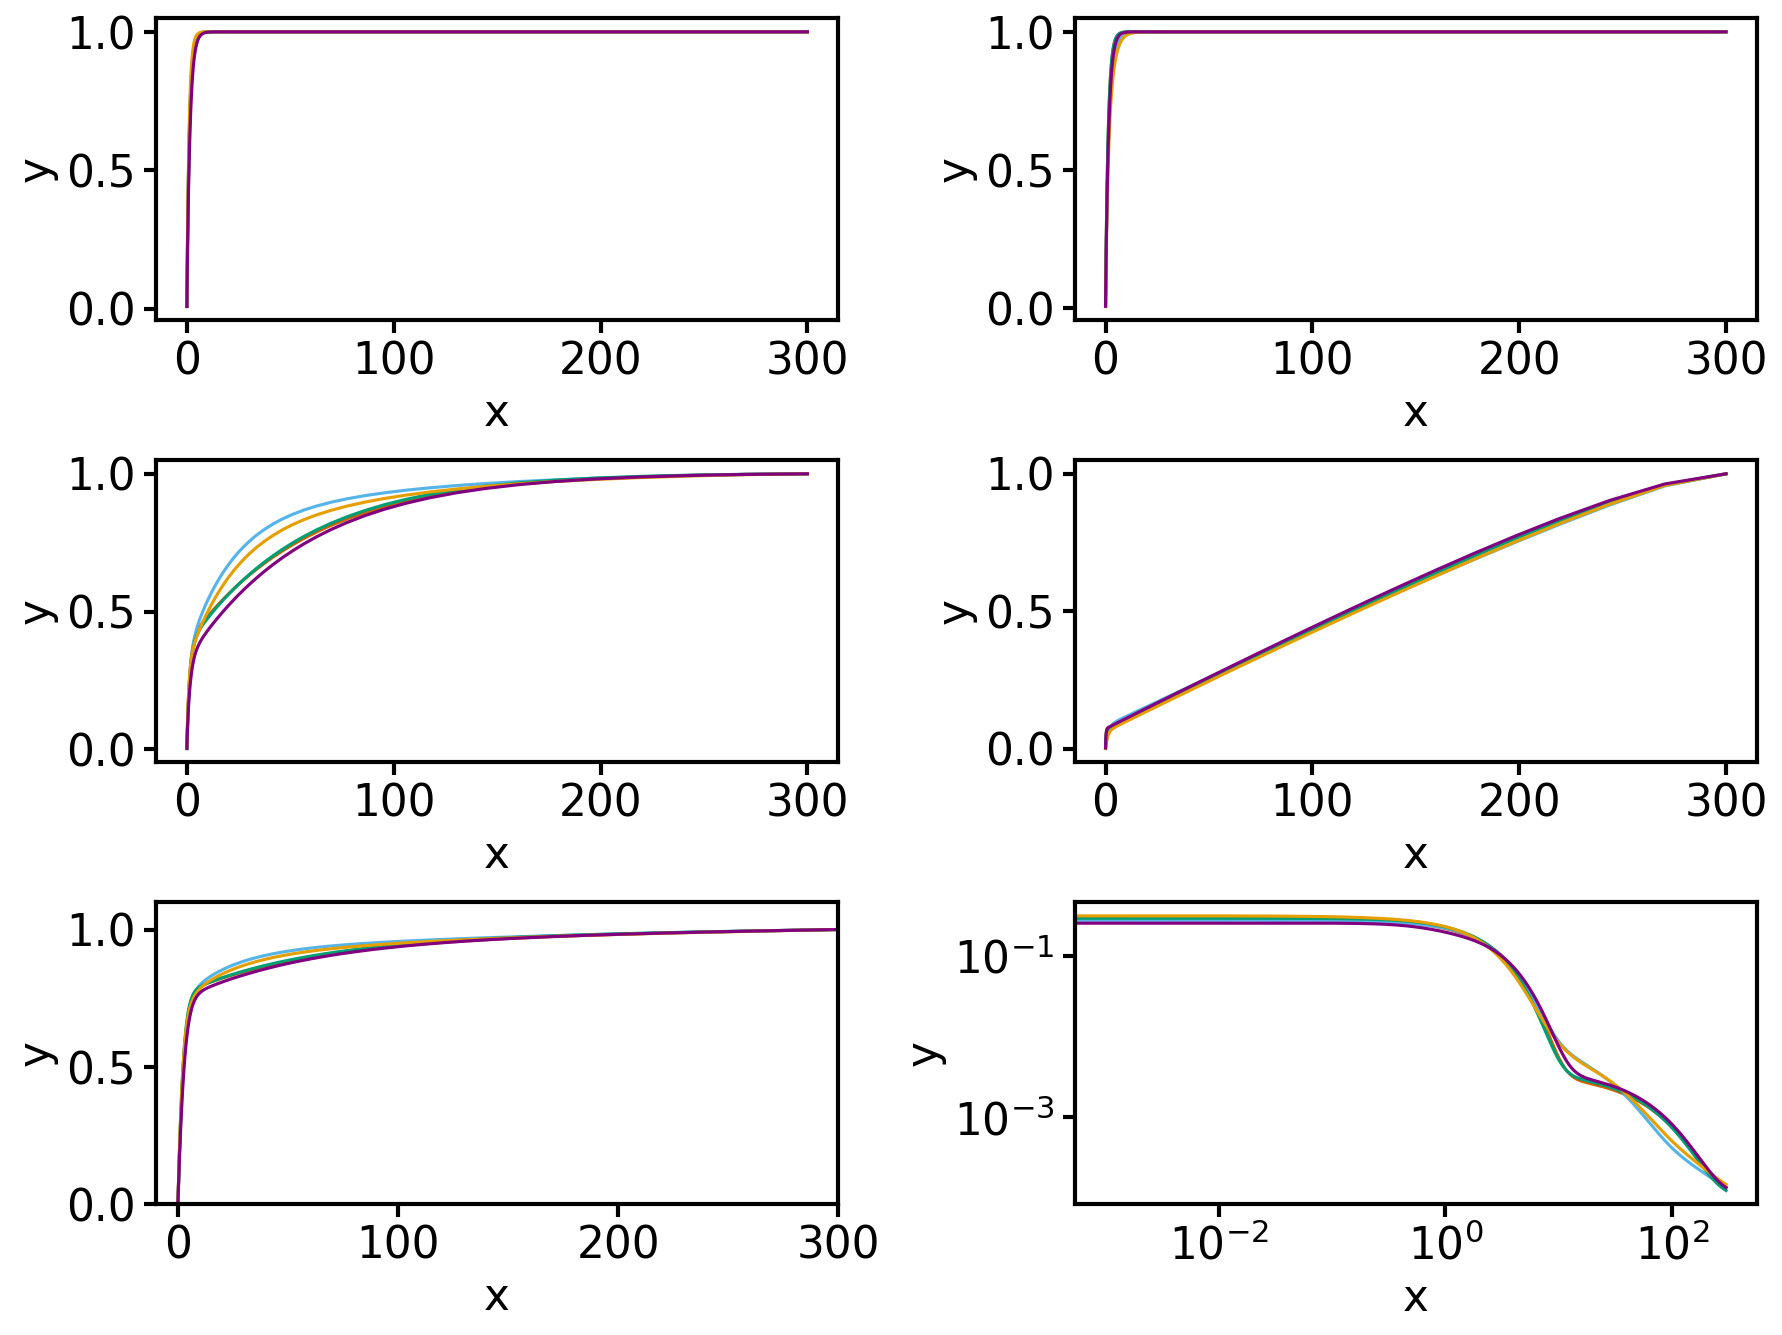

In [ ]:
rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange, "purple", "brown"]

fig, ax = plt.subplots(3, 2, figsize=(12, 9), dpi=150)
for j, params in enumerate(parameter_collector):
    params_exp_mixture = fitting.convert_dicts(params)
    color = colors[j]
    for i in range(num_f):
        if i != 0:
            pfa_cdf_part = dist.Photoswitching_fingerprint_model(
                params=params, domain=(0, 300)
            ).cdf_part
            cdf_part_index = i - 1
            cdf_marg = dist.ExponentialMixtureMarginalModel(
                params_exp_mixture[i], pfa_cdf_part, cdf_part_index, 300
            ).cdf
            use = cdf_marg
        else:
            cdf_non_marg = dist.ExponentialMixtureModel(
                params_exp_mixture[i], domain=(0, 300)
            ).cdf
            use = cdf_non_marg
        fi.universal_figure(
            data=[
                bin_edges_log,
                use(bin_edges_log),
            ],
            axes=ax.flatten()[i],
            color=color,
            label="fit",
        )
    ##########################################

    x = np.linspace(0, 300, 300001)
    cdf = dist.Photoswitching_fingerprint_model(params, None, (0, 300)).cdf
    pdf = dist.Photoswitching_fingerprint_model(params, None, (0, 300)).pdf
    fi.universal_figure(
        data=[x, cdf(x)],
        color=color,
        label="fit",
        axes=ax[2, 0],
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )

    fi.universal_figure(
        data=[x, pdf(x)],
        color=color,
        label="fit",
        axes=ax[2, 1],
        xscale="log",
        yscale="log",
    )

fig.tight_layout()

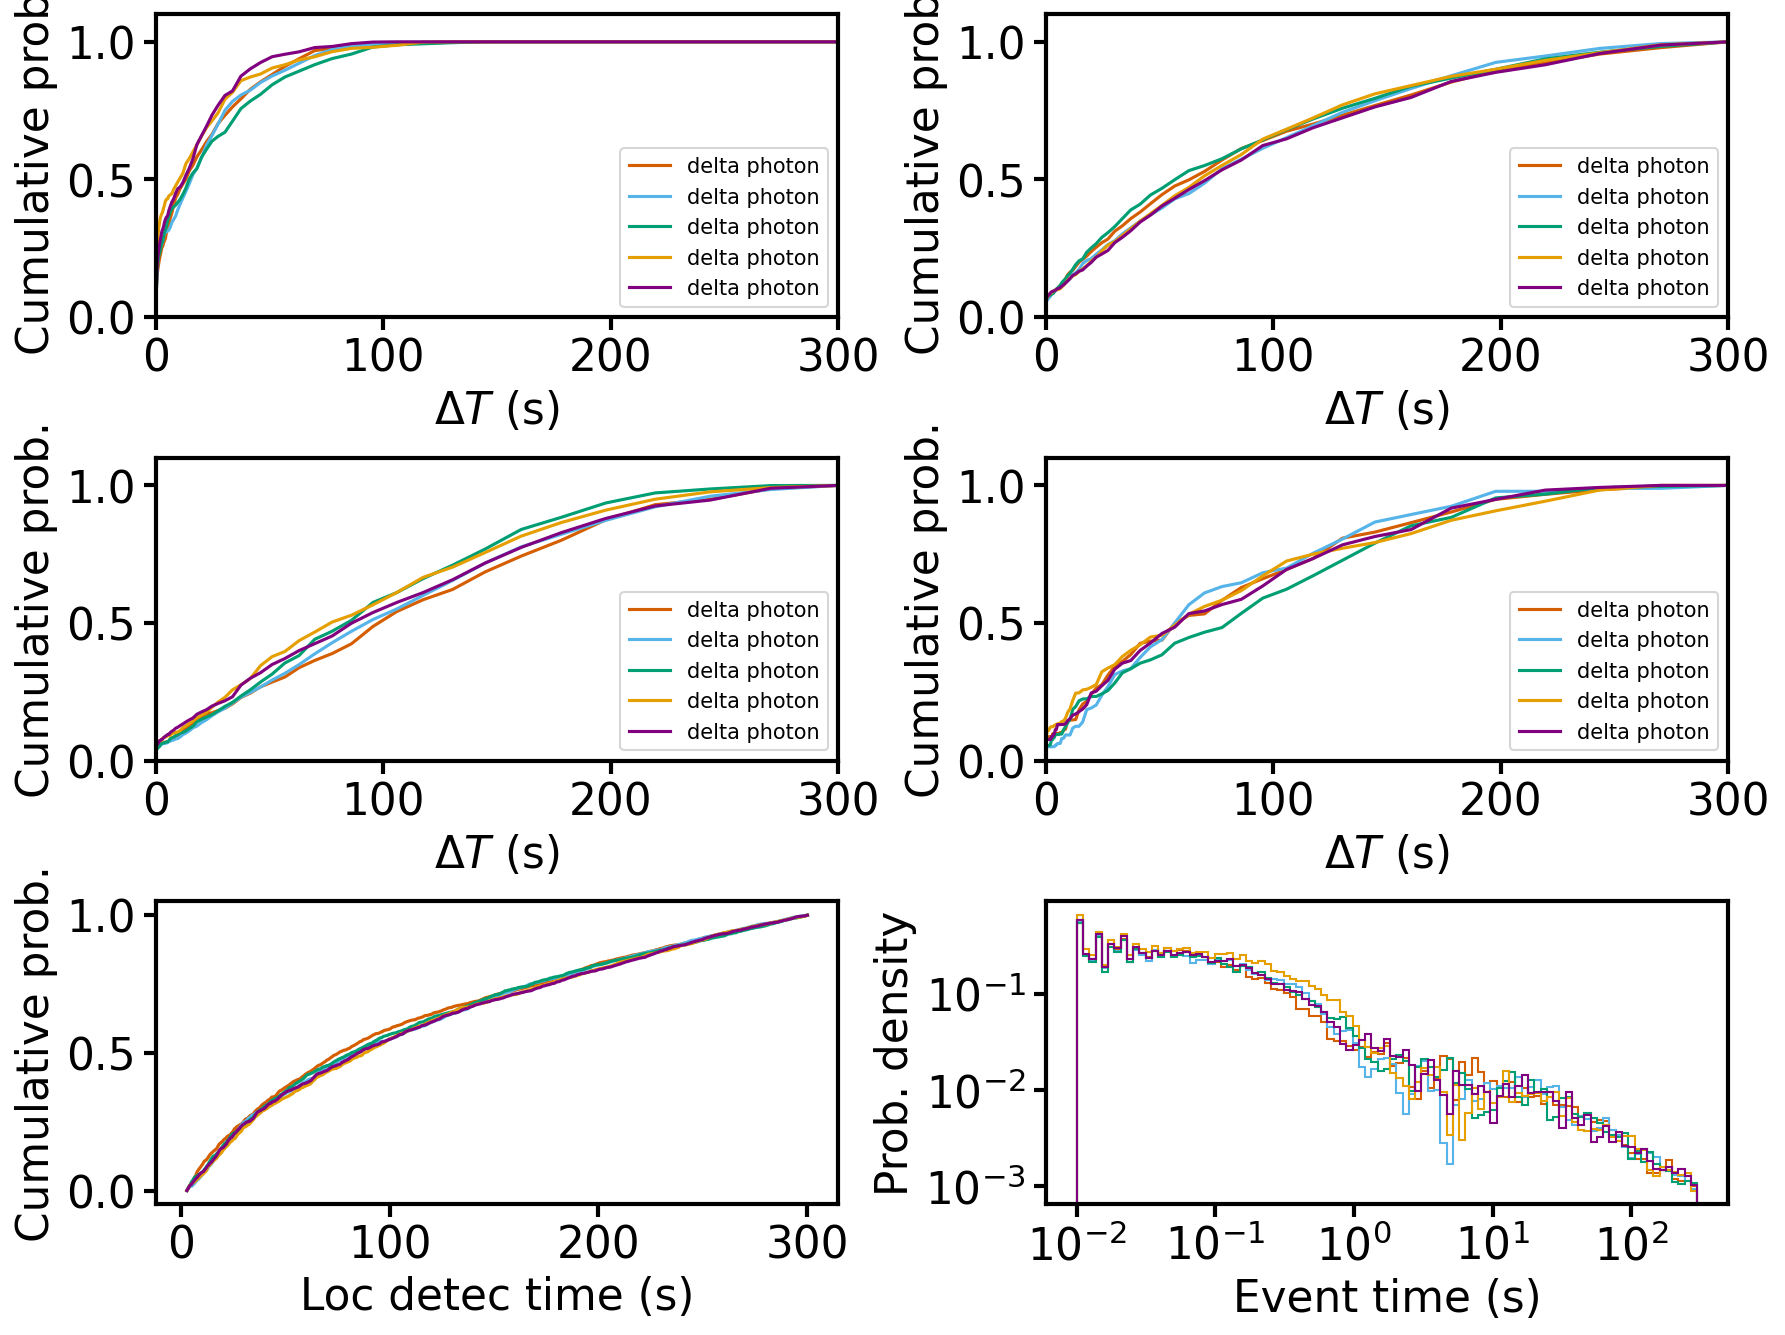

In [18]:
num_f = 4
distance = "6nm"
reading_from = (
    rf"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA\{num_f}F"
)

rcParams["axes.linewidth"] = 2
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange, "purple", "brown"]
fig, ax = plt.subplots(3, 2, figsize=(12, 9), dpi=150)
subset_size = 100
runs = int(n_runs / subset_size)
counters = []
rng = np.random.default_rng(42)

for i_run in range(runs):
    bleaching_times = np.load(reading_from + f"/bleaching_times_{distance}.npy")
    bleaching_times = bleaching_times[
        i_run * subset_size : (i_run + 1) * subset_size, :
    ]
    delta_bleaching_times = rt.get_delta_bleaching_times(bleaching_times)
    rel_num_not_observed = [
        1 - delta.size / subset_size for delta in delta_bleaching_times
    ]

    ##################################################################################
    x = np.linspace(0, 300, 300001)
    fingerprint = pd.Series(np.zeros(300001), np.round(x, decimals=12), dtype=np.int32)
    locs = pd.Series(
        np.zeros(300001),
        np.round(np.linspace(0, 300, 300001), decimals=12),
        dtype=np.int32,
    )
    bleaching_times_index = 0
    bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
    photon_arrival_times_log = np.zeros(len(bin_edges_log) - 1, dtype=int)
    delta_photon_arrival_times_binned = [
        np.zeros(len(bin_edges_log) - 1, dtype=int) for _ in range(num_f)
    ]
    rvs = []
    for counter, file in enumerate(Path(reading_from).iterdir()):
        if (
            file.suffix == ".parquet"
            and distance in file.name
            and counter not in counters
        ):
            counters.append(counter)
            df = pd.read_parquet(file)
            fingerprint += df.sum(axis=1)
            locs += (df > 0).sum(axis=1)
            for i in range(len(df.columns)):
                start_index = 0
                for n in range(num_f):
                    time_point = bleaching_times[bleaching_times_index + i, n]
                    if not np.isnan(time_point):
                        end_index = (
                            np.searchsorted(
                                df.iloc[:, i].index.values, time_point, side="right"
                            )
                            + 1
                        )
                    else:
                        end_index = df.index.size
                    data = np.repeat(
                        df.iloc[:, i].index.values[start_index:end_index],
                        df.iloc[:, i].iloc[start_index:end_index].values.astype(int),
                    )
                    rvs.extend(
                        rng.choice(data, size=int(0.1 * data.size), replace=True)
                    )
                    hist_log, _ = np.histogram(data, bins=bin_edges_log)
                    photon_arrival_times_log += hist_log
                    if data.size != 0:
                        delta_data = data - df.index.values[start_index] + 0.01
                        delta_hist, _ = np.histogram(delta_data, bins=bin_edges_log)
                        delta_photon_arrival_times_binned[n] += delta_hist
                    start_index = end_index
            bleaching_times_index += 50
            if bleaching_times_index >= subset_size:
                break

    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    locs = locs.cumsum() / locs.sum()
    locs_truncated = rt.truncate_fingerprints(locs, low=3000)
    for i, delta in enumerate(delta_photon_arrival_times_binned):
        axis = ax.flatten()[i]
        cdf = np.cumsum(delta) / delta.sum()
        cdf = np.insert(cdf, 0, 0)
        fi.universal_figure(
            data=[bin_edges_log, cdf],
            axes=axis,
            color=colors[i_run],
            label="delta photon",
            xlabel=r"$\Delta T$ (s)",
            ylabel="Cumulative prob.",
            legend=True,
            xlim=(0, 300),
            ylim=(0, 1.1),
        )
    bin_widths = np.diff(bin_edges_log)
    density = photon_arrival_times_log / (photon_arrival_times_log.sum() * bin_widths)
    fi.universal_figure(
        type_="stair",
        data=[bin_edges_log, density],
        axes=ax.flatten()[-1],
        color=colors[i_run],
        label="Photons",
        xlabel="Event time (s)",
        ylabel="Prob. density",
        xscale="log",
        yscale="log",
    )
    # fi.universal_figure(
    #     data=[fingerprint.index, fingerprint.values],
    #     axes=ax.flatten()[-2],
    #     color=colors[i_run],
    #     label="PFA",
    # )
    fi.universal_figure(
        data=[locs_truncated.index, locs_truncated.values],
        axes=ax.flatten()[-2],
        color=colors[i_run],
        label="PFA",
        ylabel="Cumulative prob.",
        xlabel="Loc detec time (s)",
    )
fig.tight_layout()